# 2. Study-Area Data Visualization

This notebook visualizes observed gravity, magnetic, and regional geology context for the Hannah and Iowa study areas using a unified figure style.


## Block 1: Hannah Observed Gravity and Magnetic Maps

Interpolate and plot Hannah gravity/magnetic observations with consistent axes, contours, and colorbar formatting.


Saved: Figure\Figure2_bcHannah_gravity_magnetic_observed_data.png


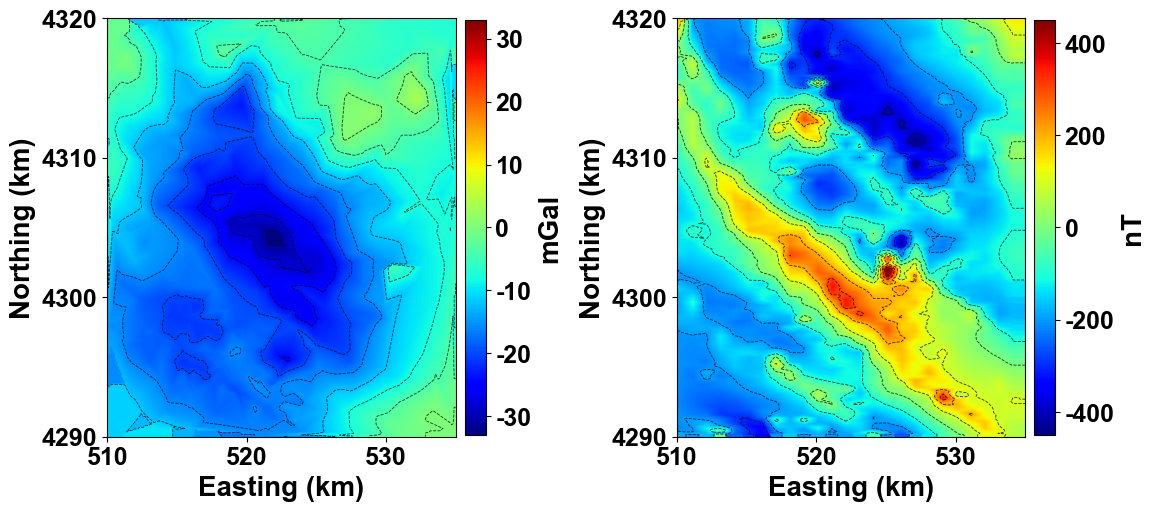

In [4]:
# -------------------------
# Block 1: Hannah Gravity and Magnetic Maps
# -------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

ROOT = Path.cwd()
project_name = "Hannah"
input_dir = ROOT / project_name

grv_csv = input_dir / f"{project_name}_gravity_data.csv"
mag_csv = input_dir / f"{project_name}_magnetic_data.csv"

# Same core region used in Hannah workflow
min_e, max_e, min_n, max_n = [510000.0, 535000.0, 4290000.0, 4320000.0]

df_grv = pd.read_csv(grv_csv)
df_mag = pd.read_csv(mag_csv)

if not ({"Easting", "Northing"} <= set(df_grv.columns)):
    raise ValueError("Gravity CSV must contain Easting/Northing columns.")
if not ({"Easting", "Northing"} <= set(df_mag.columns)):
    raise ValueError("Magnetic CSV must contain Easting/Northing columns.")

mask_grv = (
    (df_grv["Easting"] > min_e) & (df_grv["Easting"] < max_e) &
    (df_grv["Northing"] > min_n) & (df_grv["Northing"] < max_n)
)
mask_mag = (
    (df_mag["Easting"] > min_e) & (df_mag["Easting"] < max_e) &
    (df_mag["Northing"] > min_n) & (df_mag["Northing"] < max_n)
)

df_grv_core = df_grv[mask_grv].copy()
df_mag_core = df_mag[mask_mag].copy()

if df_grv_core.empty:
    raise ValueError("No Hannah gravity points found in select_region.")
if df_mag_core.empty:
    raise ValueError("No Hannah magnetic points found in select_region.")

grav_col = "ISO" if "ISO" in df_grv_core.columns else df_grv_core.columns[-1]
mag_col = "TFMA" if "TFMA" in df_mag_core.columns else df_mag_core.columns[-1]
gravity_component = "gz"
GRAVITY_UNITS = {
    "gx": "mGal", "gy": "mGal", "gz": "mGal",
    "gxx": "E", "gxy": "E", "gxz": "E", "gyy": "E", "gyz": "E", "gzz": "E",
}
grv_unit = GRAVITY_UNITS.get(gravity_component, "mGal")

# Build smooth grid (same style as magnetic panel)
nx_obs, ny_obs = 260, 260
gx_obs = np.linspace(min_e, max_e, nx_obs)
gy_obs = np.linspace(min_n, max_n, ny_obs)
GX_obs, GY_obs = np.meshgrid(gx_obs, gy_obs)

# km coordinates for plotting
min_e_km, max_e_km = min_e / 1000.0, max_e / 1000.0
min_n_km, max_n_km = min_n / 1000.0, max_n / 1000.0
GX_obs_km, GY_obs_km = GX_obs / 1000.0, GY_obs / 1000.0

# Gravity
gr_x = df_grv_core["Easting"].to_numpy()
gr_y = df_grv_core["Northing"].to_numpy()
gr_v = df_grv_core[grav_col].to_numpy()
GGRV = griddata((gr_x, gr_y), gr_v, (GX_obs, GY_obs), method="linear")
if np.isnan(GGRV).any():
    GGRV_near = griddata((gr_x, gr_y), gr_v, (GX_obs, GY_obs), method="nearest")
    GGRV = np.where(np.isnan(GGRV), GGRV_near, GGRV)

# Magnetic
mg_x = df_mag_core["Easting"].to_numpy()
mg_y = df_mag_core["Northing"].to_numpy()
mg_v = df_mag_core[mag_col].to_numpy()
GMAG = griddata((mg_x, mg_y), mg_v, (GX_obs, GY_obs), method="linear")
if np.isnan(GMAG).any():
    GMAG_near = griddata((mg_x, mg_y), mg_v, (GX_obs, GY_obs), method="nearest")
    GMAG = np.where(np.isnan(GMAG), GMAG_near, GMAG)

# Plot two subplots in one figure
fig, (ax_g, ax_m) = plt.subplots(1, 2, figsize=(11.5, 5.0), constrained_layout=True)

im_g = ax_g.imshow(
    GGRV,
    extent=[min_e_km, max_e_km, min_n_km, max_n_km],
    origin="lower",
    cmap="jet",
    interpolation="bilinear",
    vmin=-33, vmax=33,
)
ax_g.contour(
    GX_obs_km, GY_obs_km, GGRV,
    levels=10, colors="k", linewidths=0.6, linestyles="dashed", alpha=0.8,
)
ax_g.set_title("")
ax_g.set_aspect("equal", adjustable="box")
cbar_g = fig.colorbar(im_g, ax=ax_g, fraction=0.046, pad=0.02)
cbar_g.set_label(f"{grv_unit}", fontname="Arial", fontweight="bold", fontsize=20)
cbar_g.ax.tick_params(labelsize=18)
for lab in cbar_g.ax.get_yticklabels():
    lab.set_fontname("Arial")
    lab.set_fontweight("bold")

im_m = ax_m.imshow(
    GMAG,
    extent=[min_e_km, max_e_km, min_n_km, max_n_km],
    origin="lower",
    cmap="jet",
    interpolation="bilinear",
    vmin=-450, vmax=450,
)
ax_m.contour(
    GX_obs_km, GY_obs_km, GMAG,
    levels=10, colors="k", linewidths=0.6, linestyles="dashed", alpha=0.8,
)
ax_m.set_title("")
ax_m.set_aspect("equal", adjustable="box")
cbar_m = fig.colorbar(im_m, ax=ax_m, fraction=0.046, pad=0.02)
cbar_m.set_label("nT", fontname="Arial", fontweight="bold", fontsize=20)
cbar_m.ax.tick_params(labelsize=18)
for lab in cbar_m.ax.get_yticklabels():
    lab.set_fontname("Arial")
    lab.set_fontweight("bold")

# Axis labels/ticks style and fixed tick positions
xticks_km = [510, 520, 530]
yticks_km = [4290, 4300, 4310, 4320]
for ax in (ax_g, ax_m):
    ax.set_xlabel("Easting (km)", fontname="Arial", fontweight="bold", fontsize=20)
    ax.set_ylabel("Northing (km)", fontname="Arial", fontweight="bold", fontsize=20)
    ax.set_xticks(xticks_km)
    ax.set_yticks(yticks_km)
    ax.tick_params(axis="both", labelsize=18)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontname("Arial")
        lab.set_fontweight("bold")

fig_dir = ROOT / "Figure"
fig_dir.mkdir(parents=True, exist_ok=True)
out_png = fig_dir / f"Figure2_bc{project_name}_gravity_magnetic_observed_data.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved: {out_png.relative_to(ROOT)}")
plt.show()


## Block 2: Iowa Observed Gravity and Magnetic Maps

Generate Iowa gravity/magnetic maps using the same plotting conventions as Block 1 for direct comparison.


Saved: Figure\Figure3_ab_gravity_magnetic_observed_data.png


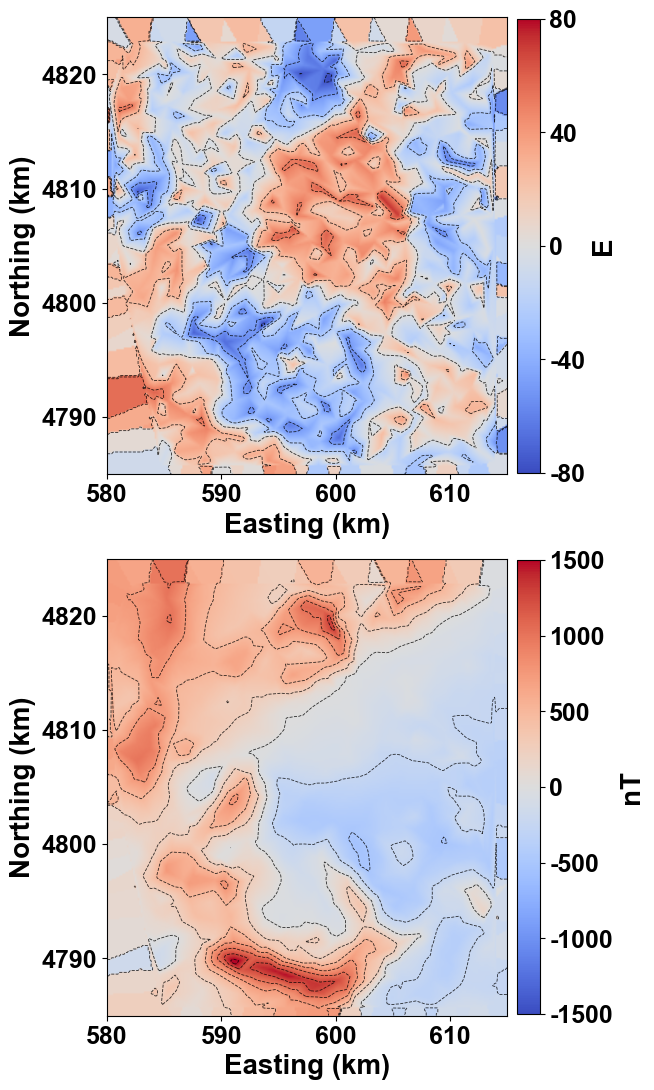

In [5]:
# -------------------------
# Block 2: Iowa Gravity and Magnetic Maps
# -------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
project_name = "Iowa"
input_dir = ROOT / project_name

grv_csv = input_dir / f"{project_name}_gravity_data.csv"
mag_csv = input_dir / f"{project_name}_magnetic_data.csv"

# Same core region used in Iowa workflow
min_e, max_e, min_n, max_n = [580000.0, 615000.0, 4785000.0, 4825000.0]

df_grv = pd.read_csv(grv_csv)
df_mag = pd.read_csv(mag_csv)

if not ({"Easting", "Northing"} <= set(df_grv.columns)):
    raise ValueError("Gravity CSV must contain Easting/Northing columns.")
if not ({"Easting", "Northing"} <= set(df_mag.columns)):
    raise ValueError("Magnetic CSV must contain Easting/Northing columns.")

mask_grv = (
    (df_grv["Easting"] > min_e) & (df_grv["Easting"] < max_e) &
    (df_grv["Northing"] > min_n) & (df_grv["Northing"] < max_n)
)
mask_mag = (
    (df_mag["Easting"] > min_e) & (df_mag["Easting"] < max_e) &
    (df_mag["Northing"] > min_n) & (df_mag["Northing"] < max_n)
)

df_grv_core = df_grv[mask_grv].copy()
df_mag_core = df_mag[mask_mag].copy()

if df_grv_core.empty:
    raise ValueError("No Iowa gravity points found in select_region.")
if df_mag_core.empty:
    raise ValueError("No Iowa magnetic points found in select_region.")

grav_col = "ISO" if "ISO" in df_grv_core.columns else df_grv_core.columns[-1]
mag_col = "TFMA" if "TFMA" in df_mag_core.columns else df_mag_core.columns[-1]
gravity_component = "gzz"
GRAVITY_UNITS = {
    "gx": "mGal", "gy": "mGal", "gz": "mGal",
    "gxx": "E", "gxy": "E", "gxz": "E", "gyy": "E", "gyz": "E", "gzz": "E",
}
grv_unit = GRAVITY_UNITS.get(gravity_component, "mGal")

# Build smooth grid (same style as magnetic panel)
nx_obs, ny_obs = 260, 260
gx_obs = np.linspace(min_e, max_e, nx_obs)
gy_obs = np.linspace(min_n, max_n, ny_obs)
GX_obs, GY_obs = np.meshgrid(gx_obs, gy_obs)

# km coordinates for plotting
min_e_km, max_e_km = min_e / 1000.0, max_e / 1000.0
min_n_km, max_n_km = min_n / 1000.0, max_n / 1000.0
GX_obs_km, GY_obs_km = GX_obs / 1000.0, GY_obs / 1000.0

# Gravity
gr_x = df_grv_core["Easting"].to_numpy()
gr_y = df_grv_core["Northing"].to_numpy()
gr_v = -df_grv_core[grav_col].to_numpy()
GGRV = griddata((gr_x, gr_y), gr_v, (GX_obs, GY_obs), method="linear")
if np.isnan(GGRV).any():
    GGRV_near = griddata((gr_x, gr_y), gr_v, (GX_obs, GY_obs), method="nearest")
    GGRV = np.where(np.isnan(GGRV), GGRV_near, GGRV)

# Magnetic
mg_x = df_mag_core["Easting"].to_numpy()
mg_y = df_mag_core["Northing"].to_numpy()
mg_v = df_mag_core[mag_col].to_numpy()
GMAG = griddata((mg_x, mg_y), mg_v, (GX_obs, GY_obs), method="linear")
if np.isnan(GMAG).any():
    GMAG_near = griddata((mg_x, mg_y), mg_v, (GX_obs, GY_obs), method="nearest")
    GMAG = np.where(np.isnan(GMAG), GMAG_near, GMAG)

# Plot vertical layout (2 rows x 1 column)
fig_v, (ax_g_v, ax_m_v) = plt.subplots(2, 1, figsize=(6.4, 10.8), constrained_layout=True)

im_g_v = ax_g_v.imshow(
    GGRV,
    extent=[min_e_km, max_e_km, min_n_km, max_n_km],
    origin="lower",
    cmap="coolwarm",
    interpolation="bilinear",
    vmin=-80,
    vmax=80,
)
ax_g_v.contour(
    GX_obs_km, GY_obs_km, GGRV,
    levels=6, colors="k", linewidths=0.6, linestyles="dashed", alpha=0.8,
)
ax_g_v.set_title("")
ax_g_v.set_xlabel("Easting (km)", fontname="Arial", fontweight="bold", fontsize=20)
ax_g_v.set_ylabel("Northing (km)", fontname="Arial", fontweight="bold", fontsize=20)
ax_g_v.set_aspect("equal", adjustable="box")
ax_g_v.set_yticks([4790, 4800, 4810, 4820])
ax_g_v.tick_params(axis="both", labelsize=18)
for lab in ax_g_v.get_xticklabels() + ax_g_v.get_yticklabels():
    lab.set_fontname("Arial")
    lab.set_fontweight("bold")
cbar_g_v = fig_v.colorbar(im_g_v, ax=ax_g_v, fraction=0.046, pad=0.02)
cbar_g_v.set_label(f"{grv_unit}", fontname="Arial", fontweight="bold", fontsize=20)
cbar_g_v.set_ticks([80, 40, 0, -40, -80])
cbar_g_v.ax.tick_params(labelsize=18)
for lab in cbar_g_v.ax.get_yticklabels():
    lab.set_fontname("Arial")
    lab.set_fontweight("bold")

im_m_v = ax_m_v.imshow(
    GMAG,
    extent=[min_e_km, max_e_km, min_n_km, max_n_km],
    origin="lower",
    cmap="coolwarm",
    interpolation="bilinear",
    vmin=-1500,
    vmax=1500,
)
ax_m_v.contour(
    GX_obs_km, GY_obs_km, GMAG,
    levels=8, colors="k", linewidths=0.6, linestyles="dashed", alpha=0.8,
)
ax_m_v.set_title("")
ax_m_v.set_xlabel("Easting (km)", fontname="Arial", fontweight="bold", fontsize=20)
ax_m_v.set_ylabel("Northing (km)", fontname="Arial", fontweight="bold", fontsize=20)
ax_m_v.set_aspect("equal", adjustable="box")
ax_m_v.set_yticks([4790, 4800, 4810, 4820])
ax_m_v.tick_params(axis="both", labelsize=18)
for lab in ax_m_v.get_xticklabels() + ax_m_v.get_yticklabels():
    lab.set_fontname("Arial")
    lab.set_fontweight("bold")
cbar_m_v = fig_v.colorbar(im_m_v, ax=ax_m_v, fraction=0.046, pad=0.02)
cbar_m_v.set_label("nT", fontname="Arial", fontweight="bold", fontsize=20)
cbar_m_v.ax.tick_params(labelsize=18)
for lab in cbar_m_v.ax.get_yticklabels():
    lab.set_fontname("Arial")
    lab.set_fontweight("bold")

fig_dir = ROOT / "Figure"
fig_dir.mkdir(parents=True, exist_ok=True)
out_png_v = fig_dir / f"Figure3_ab_gravity_magnetic_observed_data.png"
fig_v.savefig(out_png_v, dpi=600, bbox_inches="tight")
print(f"Saved: {out_png_v.relative_to(ROOT)}")
plt.show()


## Block 3: Expanded Hannah Regional Geology Panel

Build an expanded Hannah geology panel with ArcGIS overlay, core-area box, and legend of visible geologic units.


ArcGIS geology overlay loaded for expanded panel (a).
Visible geologic outcrop units in extent: 24
Saved: Figure\Figure2_a_Hannah_Geology_Map.png


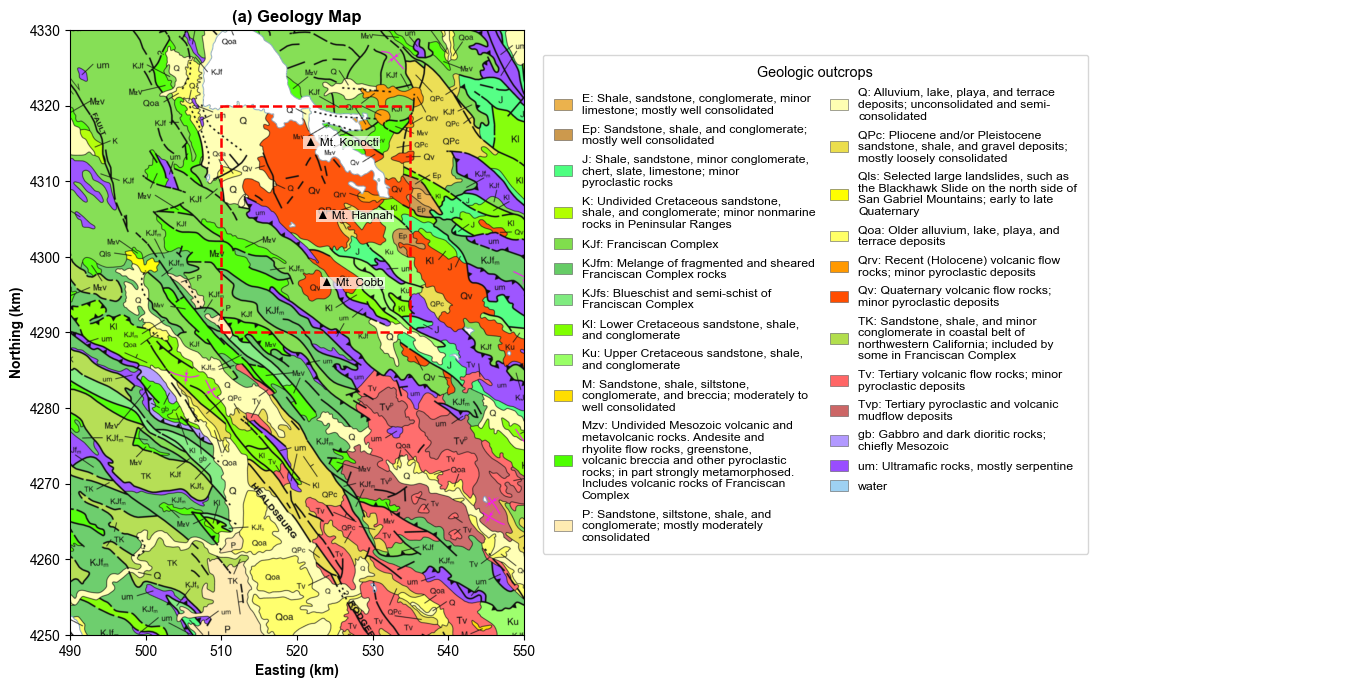

In [6]:
# -------------------------
# Block 3: Expanded Hannah Regional Geology Panel
# -------------------------
import base64
import io
import json
import re
import textwrap
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
fig_dir = ROOT / "Figure"
fig_dir.mkdir(parents=True, exist_ok=True)

# Requested extent (meters)
min_e_a, max_e_a = 490000.0, 550000.0
min_n_a, max_n_a = 4250000.0, 4330000.0

# Hannah core study area (original workflow select_region)
core_min_e, core_max_e = 510000.0, 535000.0
core_min_n, core_max_n = 4290000.0, 4320000.0

# Plot in km
min_e_a_km, max_e_a_km = min_e_a / 1000.0, max_e_a / 1000.0
min_n_a_km, max_n_a_km = min_n_a / 1000.0, max_n_a / 1000.0
core_min_e_km, core_max_e_km = core_min_e / 1000.0, core_max_e / 1000.0
core_min_n_km, core_max_n_km = core_min_n / 1000.0, core_max_n / 1000.0

# Hannah area UTM CRS
_epsg_utm = 32610

arcgis_mapserver = "https://gis.conservation.ca.gov/server/rest/services/CGS/Geologic_Map_of_California/MapServer"


def _normalize_unit_label(label):
    if label is None:
        return ""
    text = re.sub(r"<[^>]+>", "", str(label))
    text = text.replace("?", "").strip()
    text = text.replace(" ", "")
    return text


def _decode_legend_color(image_data_b64):
    try:
        rgba = plt.imread(io.BytesIO(base64.b64decode(image_data_b64)), format="png")
    except Exception:
        return (0.85, 0.85, 0.85, 1.0)

    if rgba.ndim != 3 or rgba.shape[2] < 3:
        return (0.85, 0.85, 0.85, 1.0)

    rgb = rgba[..., :3]
    if rgba.shape[2] >= 4:
        alpha = rgba[..., 3] > 0.05
        if np.any(alpha):
            rgb = rgb[alpha]
        else:
            rgb = rgb.reshape(-1, 3)
    else:
        rgb = rgb.reshape(-1, 3)

    c = np.mean(rgb, axis=0)
    return (float(c[0]), float(c[1]), float(c[2]), 1.0)


def _extract_full_name(description, general_lithology):
    desc = (description or "").strip()
    lith = (general_lithology or "").strip()
    if desc:
        desc = re.sub(r"\s+", " ", desc)
        if ":" in desc:
            head = desc.split(":", 1)[0].strip()
            if head:
                return head
        first_sentence = desc.split(".", 1)[0].strip()
        if first_sentence:
            return first_sentence

    if lith:
        return lith
    return ""

def _fetch_visible_units(mapserver_url, bbox, epsg):
    min_e, min_n, max_e, max_n = bbox
    params = {
        "f": "pjson",
        "where": "1=1",
        "geometry": f"{min_e},{min_n},{max_e},{max_n}",
        "geometryType": "esriGeometryEnvelope",
        "inSR": str(epsg),
        "spatialRel": "esriSpatialRelIntersects",
        "returnGeometry": "false",
        "outFields": "PTYPE,AGE,GENERAL_LITHOLOGY,DESCRIPTION",
        "orderByFields": "PTYPE",
        "resultRecordCount": "4000",
    }
    url = f"{mapserver_url}/12/query?{urlencode(params)}"
    with urlopen(url, timeout=90) as resp:
        data = json.loads(resp.read().decode("utf-8"))

    units = {}
    for feat in data.get("features", []):
        attr = feat.get("attributes") or {}
        ptype = (attr.get("PTYPE") or "").strip()
        if not ptype:
            continue
        if ptype not in units:
            units[ptype] = {
                "age": (attr.get("AGE") or "").strip(),
                "lith": (attr.get("GENERAL_LITHOLOGY") or "").strip(),
                "desc": (attr.get("DESCRIPTION") or "").strip(),
            }
    return units


def _fetch_unit_colors(mapserver_url):
    url = f"{mapserver_url}/legend?f=pjson"
    with urlopen(url, timeout=90) as resp:
        data = json.loads(resp.read().decode("utf-8"))

    swatch = {}
    for layer in data.get("layers", []):
        if layer.get("layerId") != 12:
            continue
        for entry in layer.get("legend", []):
            label = entry.get("label", "")
            image_data = entry.get("imageData")
            if not image_data:
                continue
            color = _decode_legend_color(image_data)

            norm_full = _normalize_unit_label(label)
            if norm_full:
                swatch.setdefault(norm_full, color)

            label_clean = re.sub(r"<[^>]+>", "", str(label))
            for part in label_clean.split(","):
                norm = _normalize_unit_label(part)
                if norm:
                    swatch.setdefault(norm, color)
        break
    return swatch


# Keep image aspect consistent with requested extent
w = max_e_a - min_e_a
h = max_n_a - min_n_a
base_px = 2400
if w >= h:
    overlay_size = (base_px, max(256, int(round(base_px * h / w))))
else:
    overlay_size = (max(256, int(round(base_px * w / h))), base_px)

arcgis_overlay_img = None
arcgis_overlay_extent = None
visible_units = {}
unit_color_lookup = {}

try:
    export_params = {
        "bbox": f"{min_e_a},{min_n_a},{max_e_a},{max_n_a}",
        "bboxSR": str(_epsg_utm),
        "imageSR": str(_epsg_utm),
        "size": f"{overlay_size[0]},{overlay_size[1]}",
        "format": "png32",
        "transparent": "true",
        "f": "pjson",
    }
    export_url = f"{arcgis_mapserver}/export?{urlencode(export_params)}"
    with urlopen(export_url, timeout=90) as resp:
        export_meta = json.loads(resp.read().decode("utf-8"))

    overlay_href = export_meta.get("href")
    overlay_ext = export_meta.get("extent", {})

    if overlay_href:
        with urlopen(overlay_href, timeout=90) as resp:
            img_bytes = resp.read()
        arcgis_overlay_img = plt.imread(io.BytesIO(img_bytes), format="png")
        arcgis_overlay_extent = [
            float(overlay_ext.get("xmin", min_e_a)),
            float(overlay_ext.get("xmax", max_e_a)),
            float(overlay_ext.get("ymin", min_n_a)),
            float(overlay_ext.get("ymax", max_n_a)),
        ]
        print("ArcGIS geology overlay loaded for expanded panel (a).")

    visible_units = _fetch_visible_units(
        arcgis_mapserver,
        (min_e_a, min_n_a, max_e_a, max_n_a),
        _epsg_utm,
    )
    unit_color_lookup = _fetch_unit_colors(arcgis_mapserver)
    print(f"Visible geologic outcrop units in extent: {len(visible_units)}")
except Exception as exc:
    print(f"[WARN] ArcGIS geology overlay/legend unavailable: {exc}")

fig = plt.figure(figsize=(16.5, 8.2), constrained_layout=False)
gs = fig.add_gridspec(1, 2, width_ratios=[0.90, 1.60], wspace=0.03)
ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])
ax_leg.axis("off")

if arcgis_overlay_img is not None and arcgis_overlay_extent is not None:
    ax.imshow(
        arcgis_overlay_img,
        extent=[
            arcgis_overlay_extent[0] / 1000.0,
            arcgis_overlay_extent[1] / 1000.0,
            arcgis_overlay_extent[2] / 1000.0,
            arcgis_overlay_extent[3] / 1000.0,
        ],
        origin="upper",
        interpolation="bilinear",
        alpha=0.95,
        zorder=2,
    )
else:
    ax.text(
        0.5,
        0.5,
        "ArcGIS geology overlay not available",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=10,
    )

ax.set_xlim(min_e_a_km, max_e_a_km)
ax.set_ylim(min_n_a_km, max_n_a_km)
ax.set_title("(a) Geology Map", fontweight="bold")
ax.set_xlabel("Easting (km)", fontweight="bold")
ax.set_ylabel("Northing (km)", fontweight="bold")
ax.set_aspect("equal", adjustable="box")

core_rect = Rectangle(
    (core_min_e_km, core_min_n_km),
    core_max_e_km - core_min_e_km,
    core_max_n_km - core_min_n_km,
    fill=False,
    edgecolor="red",
    linewidth=1.8,
    linestyle="--",
    zorder=4,
)
ax.add_patch(core_rect)


if (core_min_e < min_e_a) or (core_max_e > max_e_a) or (core_min_n < min_n_a) or (core_max_n > max_n_a):
    print("[INFO] Core-area box extends beyond current plotting extent and is clipped by axis limits.")

# Famous peaks inside current expanded extent (coordinates in EPSG:32610)
peak_labels_xy = [
    ("Mt. Konocti", 520312.5, 4313997.9),
    ("Mt. Cobb", 522527.4, 4295436.4),
    ("Mt. Hannah", 522020.4, 4304281.3),
]
for peak_name, peak_e, peak_n in peak_labels_xy:
    peak_e_km = peak_e / 1000.0
    peak_n_km = peak_n / 1000.0
    if (min_e_a_km <= peak_e_km <= max_e_a_km) and (min_n_a_km <= peak_n_km <= max_n_a_km):
        ax.text(
            peak_e_km + 0.7,
            peak_n_km + 0.7,
            f"\u25B2 {peak_name}",
            fontsize=8.5,
            color="black",
            zorder=6,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.9),
        )

# Right-side geologic legend with full names (from DESCRIPTION / GENERAL_LITHOLOGY)
geo_handles = []
for ptype in sorted(visible_units.keys()):
    info = visible_units.get(ptype, {})
    lith = info.get("lith", "")
    desc = info.get("desc", "")

    full_name = _extract_full_name(desc, lith)
    label = f"{ptype}: {full_name}" if full_name else ptype

    color = unit_color_lookup.get(ptype)
    if color is None and ptype.lower() == "water":
        color = (0.62, 0.82, 0.95, 1.0)
    if color is None:
        color = (0.85, 0.85, 0.85, 1.0)

    geo_handles.append(Patch(facecolor=color, edgecolor="0.35", linewidth=0.4, label=label))

geo_ncol = 2 if len(geo_handles) > 12 else 1
wrap_width = 40 if geo_ncol == 2 else 70
for h_ in geo_handles:
    h_.set_label(textwrap.fill(h_.get_label(), width=wrap_width))

if geo_handles:
    ax_leg.legend(
        handles=geo_handles,
        title=f"Geologic outcrops",
        loc="upper left",
        bbox_to_anchor=(0.00, 0.94),
        frameon=True,
        borderpad=0.9,
        fontsize=8.8,
        title_fontsize=10.4,
        ncol=geo_ncol,
        handlelength=1.5,
        handleheight=1.0,
        columnspacing=1.2,
        labelspacing=0.7,
        borderaxespad=0.0,
    )


out_png = fig_dir / "Figure2_a_Hannah_Geology_Map.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved: {out_png.relative_to(ROOT)}")
plt.show()
